In [5]:
from single_qubit_rcs import SingleQubitRCS
import matplotlib.pyplot as plt
import pickle

In [ ]:
# single pair (1 data + 1 ancilla), sweep depth in supremacy mode, averaged over seeds
depth_sweep = list(range(1, 31))
n_seeds = 50

results = []  # results[s][d_idx]
for seed in range(n_seeds):
    rcs = SingleQubitRCS(mode='supremacy', seed=seed)
    results.append([rcs.run_rcs(n_pairs=1, depth=d, shots=4096) for d in depth_sweep])
pickle.dump(results, open('sweep_single_pair.pkl', 'wb'))

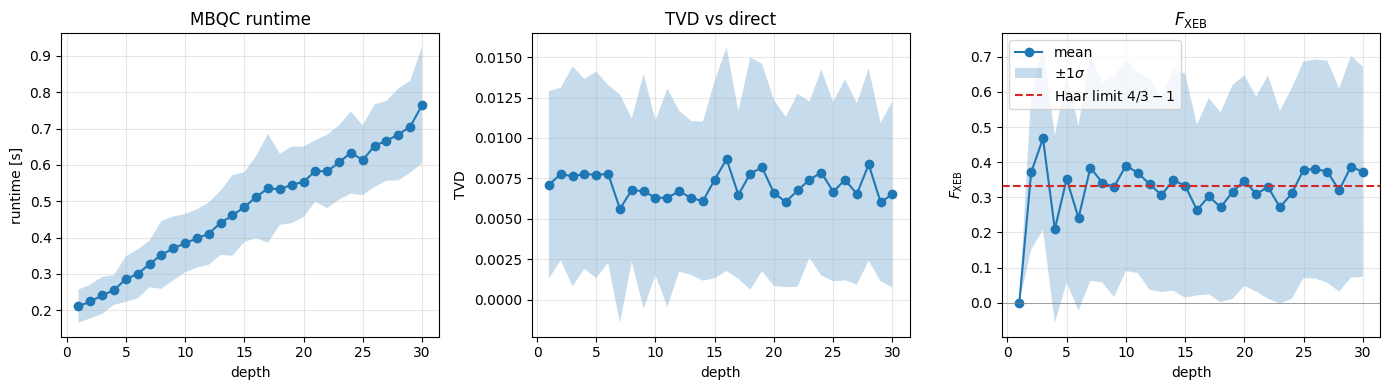

In [13]:
import numpy as np
results = pickle.load(open('sweep_single_pair.pkl', 'rb'))
depths = [r['depth'] for r in results[0]]
# stack into [n_seeds, n_depths] arrays
t_mbqc = np.array([[r['t_mbqc']   for r in seed_results] for seed_results in results])
tvds   = np.array([[r['tvd_mean'] for r in seed_results] for seed_results in results])
f_xebs = np.array([[r['f_xeb']    for r in seed_results] for seed_results in results])
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, data, ylabel, title in [
    (axes[0], t_mbqc, 'runtime [s]',     'MBQC runtime'),
    (axes[1], tvds,   'TVD',             'TVD vs direct'),
    (axes[2], f_xebs, r'$F_{\rm XEB}$',  r'$F_{\rm XEB}$'),
]:
    mean = data.mean(axis=0)
    std  = data.std(axis=0)
    ax.plot(depths, mean, 'o-', label='mean')
    ax.fill_between(depths, mean - std, mean + std, alpha=0.25, label=r'$\pm 1\sigma$')
    ax.set_ylabel(ylabel); ax.set_title(title)
    ax.set_xlabel('depth'); ax.grid(alpha=0.3)
axes[2].axhline(1/3, color='C3', ls='--', label=r'Haar limit $4/3 - 1$')
axes[2].axhline(0, color='gray', lw=0.5)
axes[2].legend()
plt.tight_layout(); plt.show()